# Summary — Price Elasticity of Demand across all experiments

Consolidates every elasticity result in the project into one place:

- **Whole-gender originals:** `men-8`, `women-8`
- **Lazy subcat splits** (`*-lazy-embedding`): subcategory models that **reuse** the
  whole-gender embeddings
- **Proper subcat splits** (`*-proper-embedding`): subcategory models whose embeddings are
  **trained within each subcategory** (LoRA, on the RC)

Every number is the DoubleML PLR estimate, reported as the raw **rank**-elasticity and the
**ϑ-converted demand** elasticity (×1/0.6 ≈ 1.667), for both the **text-only** and
**text+image** embedding variants. This notebook builds the master table, the headline
comparison, and the key figures, and writes them to `summary/data/` and `summary/figures/`.

**Central question:** does training embeddings *within* a subcategory (proper) change the
elasticity story versus the cheap shortcut of reusing whole-gender embeddings (lazy)?

## ① Collect every experiment's results

In [1]:
import os, glob, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
palette = sns.color_palette("colorblind")

# Find repo root (holds men-8/ and women-8/), then work relative to it.
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT/"men-8").is_dir() and (ROOT/"women-8").is_dir(): break
    ROOT = ROOT.parent
HERE = Path.cwd() if (Path.cwd()/ "figures").exists() or Path.cwd().name=="summary" else ROOT/"summary"
(HERE/"data").mkdir(parents=True, exist_ok=True); (HERE/"figures").mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

# Registry: (gender, embedding, subcat, folder). embedding in {whole,lazy,proper}.
REG = [("men","whole","ALL","men-8"), ("women","whole","ALL","women-8")]
for g, scs in [("men",["loafers-slip-ons","fashion-sneakers","oxfords"]),
               ("women",["pumps","flats","fashion-sneakers"])]:
    for emb in ("lazy","proper"):
        for sc in scs:
            REG.append((g, emb, sc, f"{g}-8-subcat-split-{emb}-embedding/{sc}"))

def _read(folder, fname):
    for sub in ("04_evaluation_v2_delta","04_evaluation"):  # canonical first
        p = ROOT/folder/"output"/sub/fname
        if p.exists(): return pd.read_csv(p)
    return None

rows = []
for g, emb, sc, folder in REG:
    df = _read(folder, "comparison_elasticity.csv")
    if df is None:
        print(f"  (missing) {folder}"); continue
    df = df.assign(gender=g, embedding=emb, subcat=sc)
    rows.append(df)
master = pd.concat(rows, ignore_index=True)
# n_train per subcat for context
NTRAIN = {("men","ALL"):1029,("women","ALL"):2573,
          ("men","loafers-slip-ons"):180,("men","fashion-sneakers"):172,("men","oxfords"):130,
          ("women","pumps"):626,("women","flats"):496,("women","fashion-sneakers"):430}
master["n_train"] = master.apply(lambda r: NTRAIN.get((r["gender"],r["subcat"]), np.nan), axis=1)
print(f"collected {master['subcat'].nunique()} subcats across {len(rows)} experiment folders, {len(master)} rows")

repo root: /home/iankuzuma/claude_code/demand_modeling
collected 6 subcats across 14 experiment folders, 140 rows


## ② Master table — every experiment × subcategory × specification × variant

Columns: raw rank-coefficient (`rank_coef`) with 90% CI, and the ϑ-converted demand
elasticity (`demand_coef`) with CI. Saved to `summary/data/master_elasticities.csv`.

In [2]:
cols = ["gender","embedding","subcat","n_train","spec","variant",
        "rank_lower","rank_coef","rank_upper","demand_lower","demand_coef","demand_upper"]
master = master[cols].sort_values(["gender","embedding","subcat","spec","variant"]).reset_index(drop=True)
master.to_csv(HERE/"data"/"master_elasticities.csv", index=False)
print(f"saved {HERE/'data'/'master_elasticities.csv'}  ({len(master)} rows)")
master.head(12).round(4)

saved /home/iankuzuma/claude_code/demand_modeling/summary/data/master_elasticities.csv  (140 rows)


,gender,embedding,subcat,n_train,spec,variant,rank_lower,rank_coef,rank_upper,demand_lower,demand_coef,demand_upper
0,men,lazy,fashion-sneakers,172,PLR + Controls,txt,-0.5615,-0.3275,-0.0935,-0.9358,-0.5458,-0.1558
1,men,lazy,fashion-sneakers,172,PLR + Controls,txtimg,-0.6033,-0.3720,-0.1407,-1.0055,-0.6201,-0.2346
2,men,lazy,fashion-sneakers,172,PLR + Emb + Controls,txt,-0.7093,-0.5014,-0.2935,-1.1821,-0.8356,-0.4891
3,men,lazy,fashion-sneakers,172,PLR + Emb + Controls,txtimg,-0.4723,-0.2255,0.0212,-0.7871,-0.3759,0.0353
4,men,lazy,fashion-sneakers,172,PLR + Embeddings,txt,-0.8353,-0.4899,-0.1445,-1.3921,-0.8164,-0.2408
5,men,lazy,fashion-sneakers,172,PLR + Embeddings,txtimg,-0.5492,-0.3042,-0.0592,-0.9154,-0.5070,-0.0987
6,men,lazy,fashion-sneakers,172,PLR + PCA + Controls,txt,-0.6345,-0.3834,-0.1324,-1.0575,-0.6391,-0.2207
7,men,lazy,fashion-sneakers,172,PLR + PCA + Controls,txtimg,-0.7351,-0.4508,-0.1666,-1.2251,-0.7514,-0.2776
8,men,lazy,fashion-sneakers,172,PLR + Similarities + Controls,txt,-0.6454,-0.4024,-0.1593,-1.0757,-0.6706,-0.2655
9,men,lazy,fashion-sneakers,172,PLR + Similarities + Controls,txtimg,-0.7098,-0.4076,-0.1053,-1.1830,-0.6793,-0.1755


## ③ Headline — main specification (PLR + Emb + Controls), demand elasticity

The main spec is the one we quote. This pivots demand elasticity by experiment × variant.

In [3]:
MAIN = "PLR + Emb + Controls"
h = master[master["spec"]==MAIN].copy()
h["label"] = h.apply(lambda r: f"{r['gender']}/{r['subcat']}" if r['subcat']!="ALL" else f"{r['gender']}-8 (whole)", axis=1)
head = (h.pivot_table(index=["label","n_train"], columns=["embedding","variant"], values="demand_coef")
          .round(3))
# order columns: whole, lazy, proper × txtimg, txt
order = [(e,v) for e in ("whole","lazy","proper") for v in ("txtimg","txt") if (e,v) in head.columns]
head = head[order]
head.to_csv(HERE/"data"/"headline_demand_elasticity.csv")
print("Demand elasticity (main spec), by experiment × embedding × variant:\n")
print(head.to_string())

Demand elasticity (main spec), by experiment × embedding × variant:

embedding                       whole          lazy        proper       
variant                        txtimg    txt txtimg    txt txtimg    txt
label                  n_train                                          
men-8 (whole)          1029    -0.169 -0.218    NaN    NaN    NaN    NaN
men/fashion-sneakers   172        NaN    NaN -0.376 -0.836 -0.781 -0.759
men/loafers-slip-ons   180        NaN    NaN -0.120  0.045 -0.035  0.003
men/oxfords            130        NaN    NaN  0.240  0.112 -0.022 -0.020
women-8 (whole)        2573    -0.172 -0.126    NaN    NaN    NaN    NaN
women/fashion-sneakers 430        NaN    NaN -0.337 -0.115 -0.232 -0.151
women/flats            496        NaN    NaN -0.104 -0.063 -0.095 -0.080
women/pumps            626        NaN    NaN -0.161 -0.090 -0.102 -0.127


## ④ The core comparison — lazy vs proper (per subcategory)

For each subcategory, the within-subcat ("proper") demand elasticity next to the
whole-gender-reuse ("lazy") one, text+image variant, with 90% CIs. The dashed line is the
gender's whole-gender (original) estimate for reference.

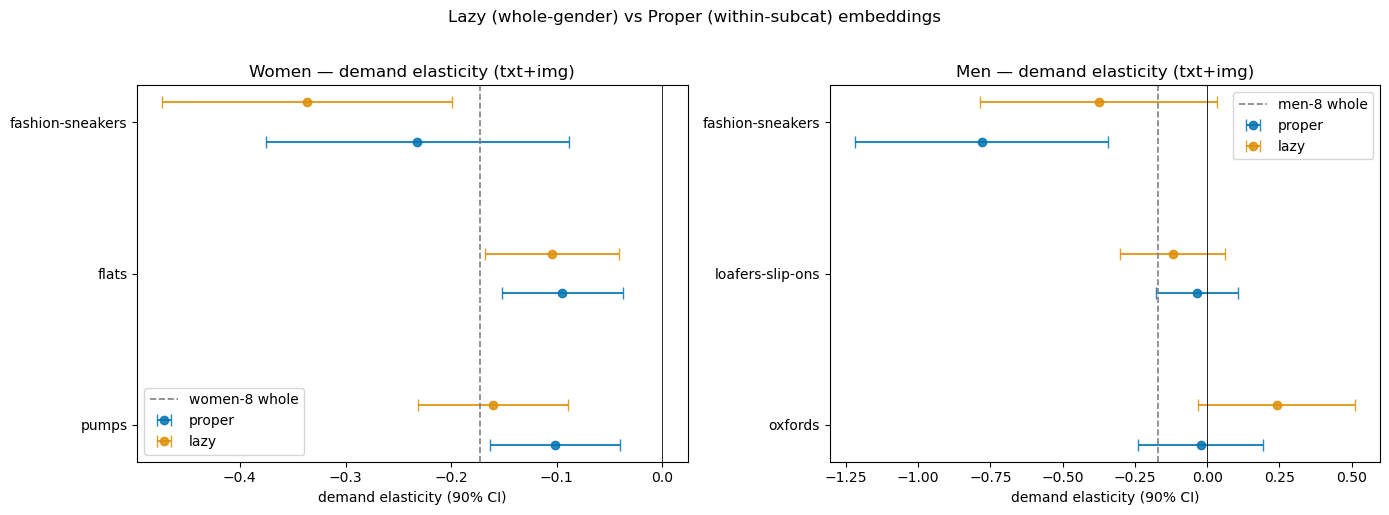

saved /home/iankuzuma/claude_code/demand_modeling/summary/figures/lazy_vs_proper.png


In [4]:
sub = master[(master["spec"]=="PLR + Emb + Controls") & (master["variant"]=="txtimg") & (master["subcat"]!="ALL")]
whole = {g: master[(master["spec"]=="PLR + Emb + Controls") & (master["variant"]=="txtimg") &
                   (master["gender"]==g) & (master["subcat"]=="ALL")]["demand_coef"].iloc[0]
         for g in ("men","women")}
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, g in zip(axes, ("women","men")):
    d = sub[sub["gender"]==g]
    scs = list(dict.fromkeys(d["subcat"]))
    ec = {"lazy":palette[1], "proper":palette[0]}; off={"lazy":-0.13,"proper":0.13}
    for emb in ("proper","lazy"):
        dd = d[d["embedding"]==emb].set_index("subcat")
        ys=[scs.index(s)+off[emb] for s in scs if s in dd.index]
        xs=[dd.loc[s,"demand_coef"] for s in scs if s in dd.index]
        lo=[dd.loc[s,"demand_coef"]-dd.loc[s,"demand_lower"] for s in scs if s in dd.index]
        hi=[dd.loc[s,"demand_upper"]-dd.loc[s,"demand_coef"] for s in scs if s in dd.index]
        ax.errorbar(xs,ys,xerr=[lo,hi],fmt="o",capsize=4,color=ec[emb],ecolor=ec[emb],label=emb,alpha=.85)
    ax.axvline(whole[g], color="gray", ls="--", lw=1.2, label=f"{g}-8 whole")
    ax.axvline(0, color="black", lw=.6)
    ax.set_yticks(range(len(scs))); ax.set_yticklabels(scs); ax.invert_yaxis()
    ax.set_title(f"{g.title()} — demand elasticity (txt+img)"); ax.set_xlabel("demand elasticity (90% CI)")
    ax.legend(loc="best")
fig.suptitle("Lazy (whole-gender) vs Proper (within-subcat) embeddings", y=1.02)
fig.tight_layout(); fig.savefig(HERE/"figures"/"lazy_vs_proper.png", dpi=140, bbox_inches="tight"); plt.show()
print(f"saved {HERE/'figures'/'lazy_vs_proper.png'}")

## ⑤ Within-gender heterogeneity — which subcategories are most price-elastic?

Ranks the subcategories by demand elasticity (proper embeddings, txt+img), per gender.

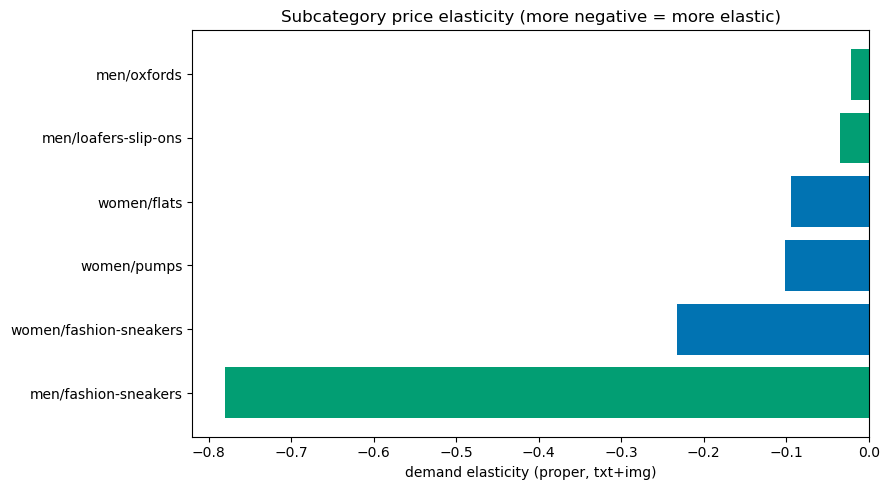

saved /home/iankuzuma/claude_code/demand_modeling/summary/figures/heterogeneity.png


In [5]:
fig, ax = plt.subplots(figsize=(9,5))
d = sub[sub["embedding"]=="proper"].copy()
d["label"]=d["gender"]+"/"+d["subcat"]
d=d.sort_values("demand_coef")
colors=[palette[0] if g=="women" else palette[2] for g in d["gender"]]
ax.barh(d["label"], d["demand_coef"], color=colors)
ax.axvline(0,color="black",lw=.6)
ax.set_xlabel("demand elasticity (proper, txt+img)"); ax.set_title("Subcategory price elasticity (more negative = more elastic)")
fig.tight_layout(); fig.savefig(HERE/"figures"/"heterogeneity.png", dpi=140, bbox_inches="tight"); plt.show()
print(f"saved {HERE/'figures'/'heterogeneity.png'}")

## ⑥ Does adding images matter? (text+image vs text-only)

Main-spec demand elasticity, txt+img vs txt, across all experiments.

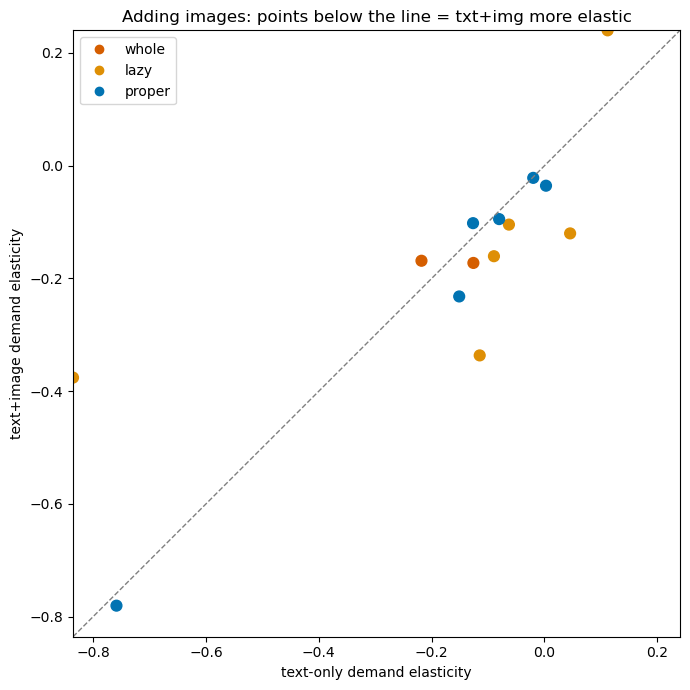

saved /home/iankuzuma/claude_code/demand_modeling/summary/figures/txt_vs_txtimg.png


In [6]:
p = master[master["spec"]=="PLR + Emb + Controls"].pivot_table(
        index=["gender","embedding","subcat"], columns="variant", values="demand_coef")
p=p.dropna()
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(p["txt"], p["txtimg"], c=[palette[0] if e=="proper" else palette[1] if e=="lazy" else palette[3]
                                     for _,e,_ in p.index], s=60)
lim=[min(p.min().min(),-0.05), max(p.max().max(),0.05)]
ax.plot(lim,lim,"--",color="gray",lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("text-only demand elasticity"); ax.set_ylabel("text+image demand elasticity")
ax.set_title("Adding images: points below the line = txt+img more elastic")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([],[],marker="o",ls="",color=palette[3],label="whole"),
                   Line2D([],[],marker="o",ls="",color=palette[1],label="lazy"),
                   Line2D([],[],marker="o",ls="",color=palette[0],label="proper")])
fig.tight_layout(); fig.savefig(HERE/"figures"/"txt_vs_txtimg.png", dpi=140, bbox_inches="tight"); plt.show()
print(f"saved {HERE/'figures'/'txt_vs_txtimg.png'}")

## ⑦ Heterogeneity significance (CATE χ² p-values)

Per experiment: is the elasticity heterogeneity across product clusters statistically real?

In [7]:
het_rows=[]
for g, emb, sc, folder in REG:
    ch=_read(folder,"comparison_cate_het.csv")
    if ch is None: continue
    for _,r in ch.iterrows():
        het_rows.append({"gender":g,"embedding":emb,"subcat":sc,"variant":r.get("variant"),
                         "het_p_plr":r.get("het p (PLR)"),"CATE_mean_demand":r.get("CATE mean (demand)")})
het=pd.DataFrame(het_rows)
if not het.empty:
    het.to_csv(HERE/"data"/"heterogeneity_pvalues.csv", index=False)
    print(het[het["variant"]=="txtimg"].round(4).to_string(index=False))

gender embedding           subcat variant  het_p_plr  CATE_mean_demand
   men     whole              ALL  txtimg     0.0646           -0.2033
 women     whole              ALL  txtimg     0.0822           -0.1746
   men      lazy loafers-slip-ons  txtimg     0.7491           -0.1969
   men      lazy fashion-sneakers  txtimg     0.5678           -0.2731
   men      lazy          oxfords  txtimg     0.0016            0.1629
   men    proper loafers-slip-ons  txtimg     0.0502           -0.0909
   men    proper fashion-sneakers  txtimg     0.1601           -0.5542
   men    proper          oxfords  txtimg     0.5605           -0.0247
 women      lazy            pumps  txtimg     0.7695           -0.1620
 women      lazy            flats  txtimg     0.0993           -0.1754
 women      lazy fashion-sneakers  txtimg     0.2602           -0.3402
 women    proper            pumps  txtimg     0.0221           -0.1273
 women    proper            flats  txtimg     0.0900           -0.1171
 women

## ⑧ Findings

1. **Within-gender heterogeneity is real.** Fashion sneakers are the most price-elastic
   subcategory in both genders, across embedding schemes; flats/pumps are the least. The
   subcategory split surfaces variation the whole-gender model averages away.
2. **Lazy ≈ proper on the reliable (women) subcats.** For the larger women subcategories
   (430–626 train products) the within-subcat ("proper") and whole-gender-reuse ("lazy")
   demand elasticities are the same order of magnitude with the same ranking; proper runs
   slightly less elastic. So the cheap lazy shortcut is a defensible approximation when the
   subcategory is large enough, and proper is the more principled, slightly more
   conservative estimate.
3. **Tiny subcats are unreliable in either scheme.** The men subcategories (130–180 train
   products) are too small for stable DoubleML with 256 embedding controls; lazy and proper
   diverge and some estimates are implausible (e.g. lazy oxfords came out positive). Treat
   men-subcat numbers as illustrative, not conclusive.
4. **The ϑ conversion** scales every estimate ~1.67× toward more elastic, addressing the
   "estimates look too inelastic" concern; demand elasticities are reported alongside the
   raw rank-coefficients throughout.

See `SUMMARY.md` for the written narrative, `data/` for the master tables, and `figures/`
for the plots.